## HateXplain - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech - general
* **Target 2:** Hate speech against woman

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import random
import torch
import numpy as np
from datasets import load_dataset

In [7]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.old.visualization import plot_pareto_2d
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [8]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [9]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [11]:
task_config = {
    "hate_speech": {"type": "hate_speech"},
    "women_hate": {"type": "group_hate", "group": "Women"},
    #"homosexual_hate": {"type": "group_hate", "group": "Homosexual"},
    #"indigenous_hate": {"type": "group_hate", "group": "Indigenous"},
    #"african_hate": {"type": "group_hate", "group": "African"},
    #"asian_hate": {"type": "group_hate", "group": "Asian"},
    #"jewish_hate": {"type": "group_hate", "group": "Jewish"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:47<00:00, 10.07it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [12]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

17:20:09 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
17:20:09 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3:  66%|██████▌   | 158/241 [00:01<00:00, 112.05it/s]


KeyboardInterrupt: 

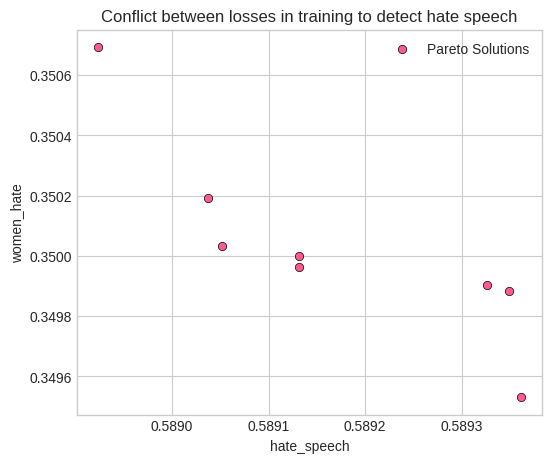

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_pareto_2d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

14:49:20 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
14:49:20 | DEBUG | ml_moo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:01<00:00, 123.67it/s]


Epoch 1 - Average loss: 0.3663


Epoch 2/3: 100%|██████████| 241/241 [00:01<00:00, 128.51it/s]


Epoch 2 - Average loss: 0.3591


Epoch 3/3: 100%|██████████| 241/241 [00:01<00:00, 124.53it/s]


...

Epoch 2 - Average loss: 0.2699


Epoch 3/3: 100%|██████████| 241/241 [00:01<00:00, 120.84it/s]


Epoch 3 - Average loss: 0.2699


15:08:36 | DEBUG | ml_moo | Calculated weights: [0.71886375 0.28113625]
15:08:36 | DEBUG | ml_moo | Importance: 5.452141252215714e-05
15:08:36 | DEBUG | ml_moo | Global lower bound (y*): [0.58904205 0.34962261]
15:08:36 | DEBUG | ml_moo | Iteration 151
15:08:36 | DEBUG | ml_moo | Solutions list: [array([0.58912218, 0.35013889]), array([0.58920654, 0.3500087 ]), array([0.58927274, 0.34969535]), array([0.58938496, 0.34962261]), array([0.58918268, 0.35000974]), array([0.58904205, 0.35028522])]


new solution dominated [0.58917029 0.35015804]


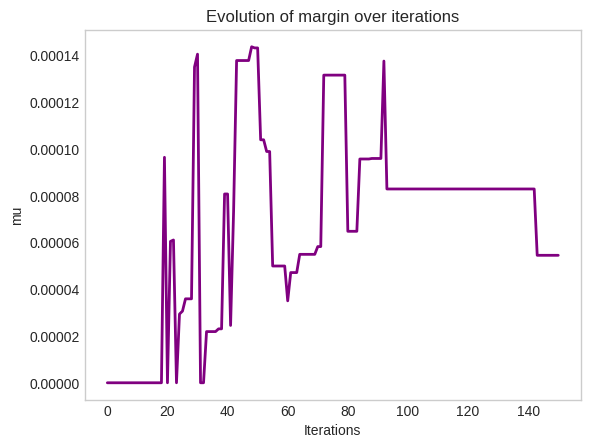

15:08:36 | INFO | ml_moo | Fit runtime: 1155.53 seconds


In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

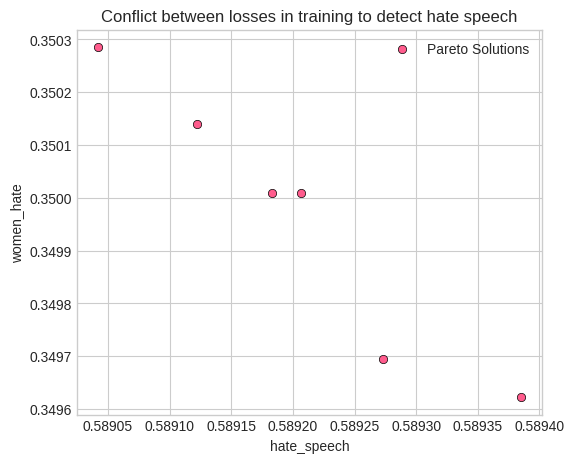

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_pareto_2d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

### Random Weight

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

15:08:36 | WARNING | ml_moo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
15:08:36 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
15:08:36 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 116.31it/s]


Epoch 1 - Average loss: 0.3672


Epoch 2/3: 100%|██████████| 241/241 [00:01<00:00, 123.73it/s]


Epoch 2 - Average loss: 0.3587


Epoch 3/3: 100%|██████████| 241/241 [00:01<00:00, 121.72it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:01<00:00, 122.42it/s]


Epoch 2 - Average loss: 0.2438


Epoch 3/3: 100%|██████████| 241/241 [00:01<00:00, 123.94it/s]


Epoch 3 - Average loss: 0.2436


15:27:40 | DEBUG | ml_moo.moo.random_weights | 150th solution


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [ ]:
from machinemoo.analysis.moo_analyzer import Analyzer

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = task_names
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      #point = equal.objs,
                      axis_label=axis_label
                      )

AttributeError: type object 'Analyzer' has no attribute 'run_multiple'

In [ ]:
from machinemoo.analysis.visualization import plot_pareto_2d_set_limit

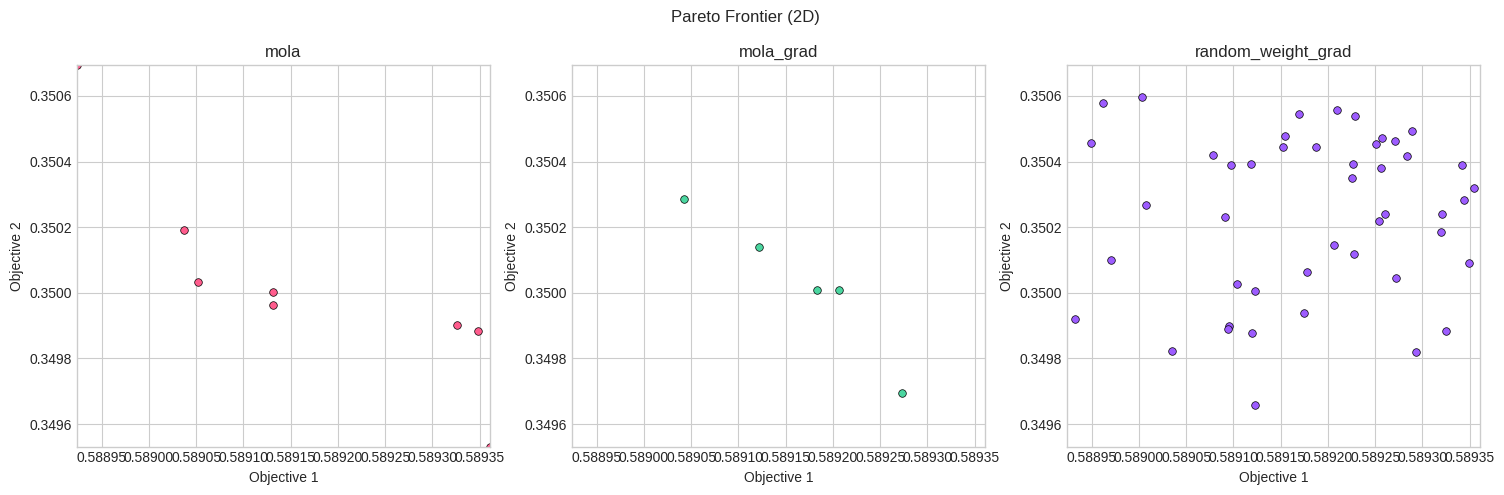

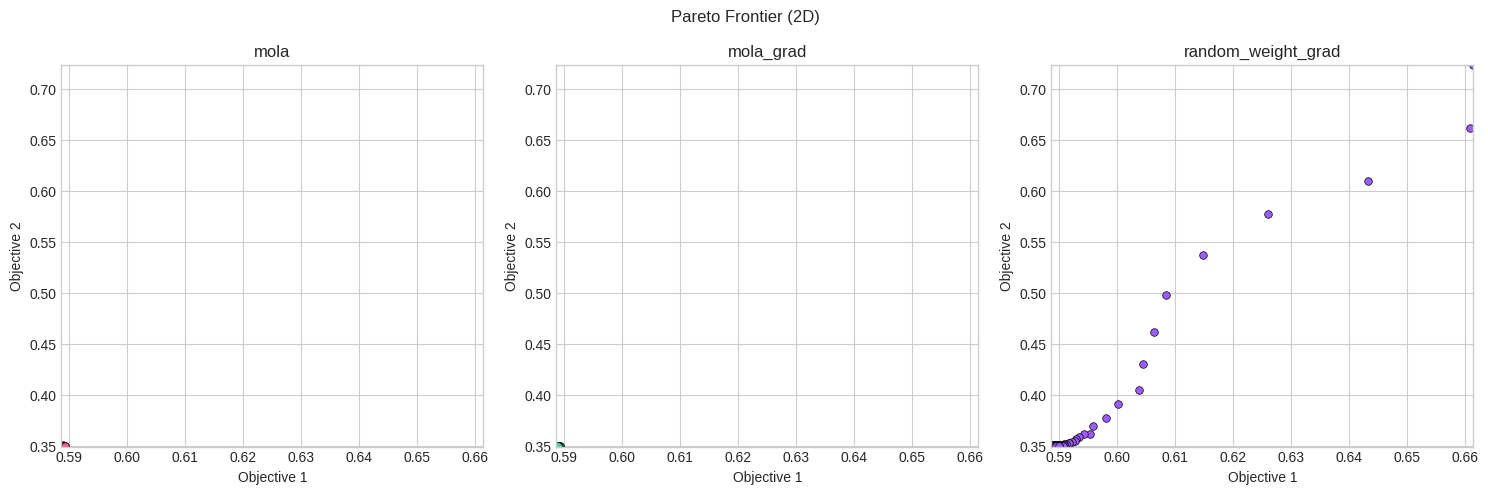

In [ ]:
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 